ARTI406 - Machine Learning

# Assignment 1: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values?
- Are there outliers?
- What patterns exist?
- Which variables influence others?

If we do not understand the data, we cannot build a good model.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on understanding and cleaning data
    2- Only 20–30% is spent building models

**EDA helps us:**

- Detect errors
- Identify trends
- Discover relationships
- Make business decisions

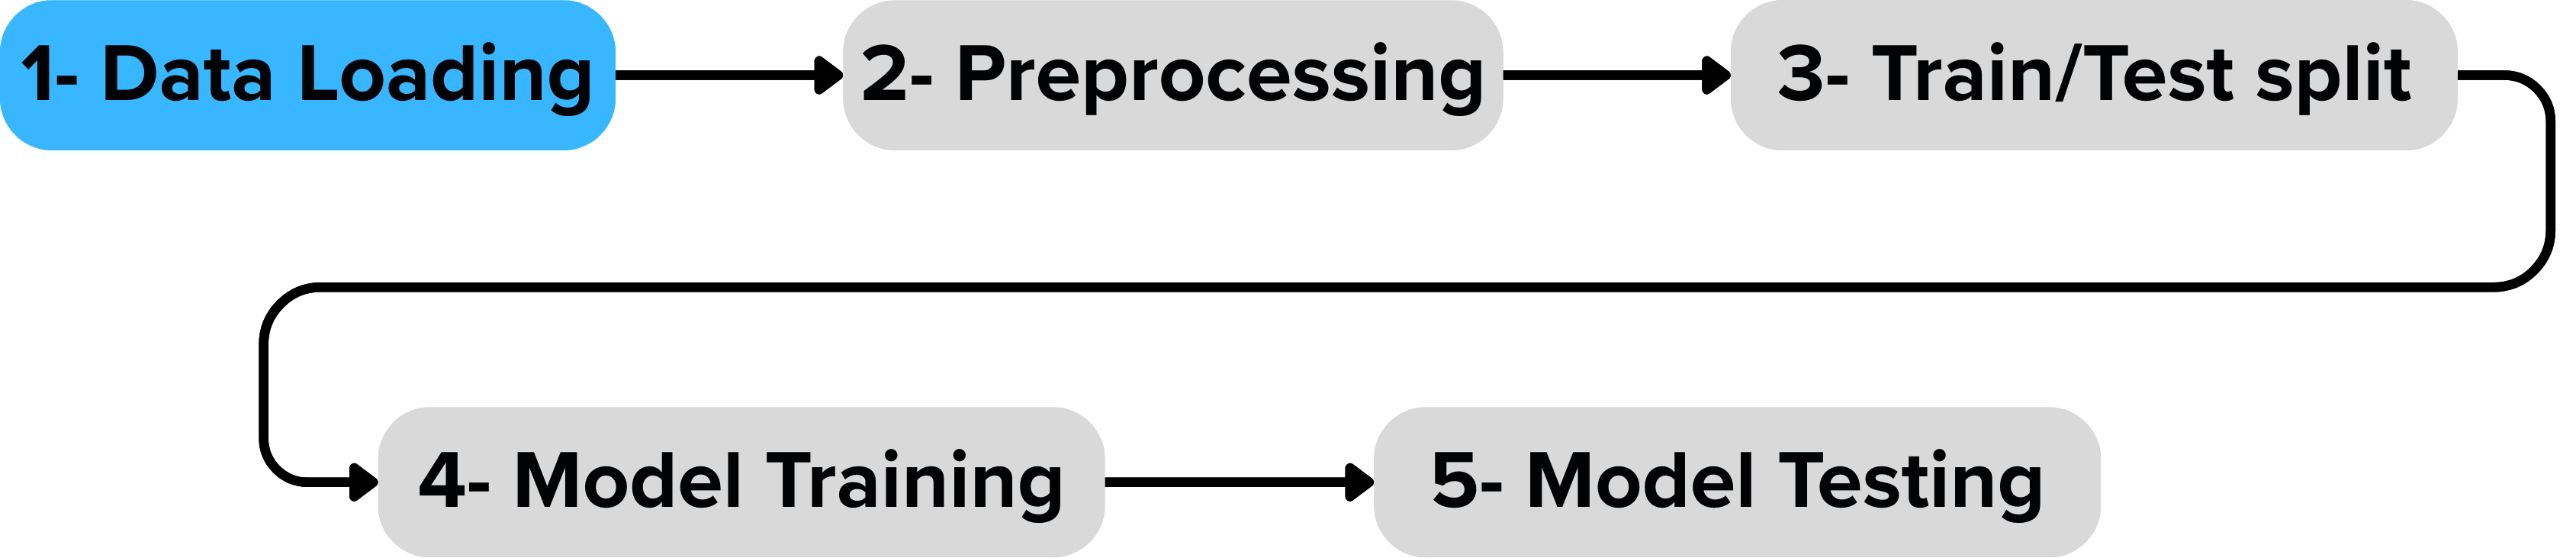

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [2]:
# Load Dataset
df = pd.read_csv("Customer_support_data.csv")
# Display first 5 rows. If you want to display all rows, use df.head(-1)
df.head(-1)

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85901,2f4c7a58-c23b-4933-b65e-b6dbbb368b49,Inbound,Order Related,Order status enquiry,NaN,0cf9615a-60e7-4696-b679-a5602634fb29,28/08/2023 18:48,29/08/2023 19:13,31/08/2023 15:11,31-Aug-23,IBRAHIMPATNAM,Mobile,23999.0,NaN,William Hall,Isabella Wong,John Smith,>90,Morning,5
85902,505ea5e7-c475-4fac-ac36-1d19a4cb610f,Inbound,Refund Related,Refund Enquiry,NaN,1b5a2b9c-a95f-405f-a42e-5b1b693f3dc9,NaN,30/08/2023 23:20,31/08/2023 07:22,31-Aug-23,NaN,NaN,NaN,NaN,Brandon Leon,Ethan Tan,William Kim,On Job Training,Morning,4
85903,44b38d3f-1523-4182-aba2-72917586647c,Inbound,Order Related,Seller Cancelled Order,Supported team customer executive good,d0e8a817-96d5-4ace-bb82-adec50398e22,NaN,31/08/2023 08:15,31/08/2023 08:17,31-Aug-23,NaN,NaN,NaN,NaN,Linda Foster,Noah Patel,Emily Chen,>90,Morning,5
85904,723bce2c-496c-4aa8-a64b-ca17004528f0,Inbound,Order Related,Order status enquiry,need to improve with proper details.,bdefe788-ccec-4eda-8ca4-51045e68db8a,NaN,31/08/2023 18:57,31/08/2023 19:02,31-Aug-23,NaN,NaN,NaN,NaN,Kimberly Martinez,Aiden Patel,Olivia Tan,On Job Training,Evening,5


In [6]:
#used to identify the number of rows and columns in the dataset
df.shape 

(85907, 20)

In [7]:
#provides information about the dataset, including data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

In [8]:
#shows statistical summaries of numerical columns such as mean, minimum, and maximum values
df.describe()

,Item_price,connected_handling_time,CSAT Score
count,17206.000000,242.000000,85907.000000
mean,5660.774846,462.400826,4.242157
std,12825.728411,246.295037,1.378903
min,0.000000,0.000000,1.000000
25%,392.000000,293.000000,4.000000
50%,979.000000,427.000000,5.000000
75%,2699.750000,592.250000,5.000000
max,164999.000000,1986.000000,5.000000


In [47]:
# Before cleaning
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
11,4c28acf4-2ea4-4be8-b8f1-113e676fc8b7,Inbound,Order Related,Delayed,Very bad,55bbace3-eb2e-4f67-aacb-4f8ee8512f75,2023-07-19 23:50:00,02/08/2023 10:44,02/08/2023 11:14,02-Aug-23,NAGPUR,LifeStyle,434.0,427.0,Stanley Hogan,Harper Wong,Emily Chen,>90,Split,1
12,e7ec72bb-65e9-4464-9c2b-8ce6b0e82a28,Inbound,Shopzilla Related,General Enquiry,Unknown,c7d5eef8-d239-474c-8d24-542db2923b3c,2023-07-19 23:50:00,01/08/2023 10:09,01/08/2023 10:12,01-Aug-23,Unknown,Unknown,979.0,427.0,Timothy Scott,Zoe Yamamoto,William Kim,On Job Training,Morning,4
13,68c596f2-4130-42f9-a140-b336261b1629,Inbound,Shopzilla Related,General Enquiry,Unknown,c1e10375-7426-4b2a-aca6-17dc6bc9c7a3,2023-07-19 23:50:00,01/08/2023 10:15,01/08/2023 11:21,01-Aug-23,Unknown,Unknown,979.0,427.0,Shannon Hicks,Aiden Patel,Olivia Tan,>90,Morning,4
14,6b966653-0900-4d58-8b38-c17cfbdaf000,Inbound,Returns,Reverse Pickup Enquiry,Unknown,9e0d7d55-d012-42f7-8e21-634942419386,2023-07-19 23:50:00,02/08/2023 11:26,02/08/2023 11:44,02-Aug-23,Unknown,Unknown,979.0,427.0,Mark Wilson,Scarlett Chen,John Smith,0-30,Morning,5
15,130dfefe-1d77-47f9-b759-546f24b6b909,Inbound,Returns,Missing,Unknown,8153c646-4940-406f-992c-952ed08e9af8,2023-07-19 23:50:00,02/08/2023 19:56,02/08/2023 20:06,02-Aug-23,Unknown,Unknown,979.0,427.0,Mark Black,Sophia Sato,John Smith,>90,Afternoon,5


## Data Cleaning

### Check Missing Values

In [11]:
# Check all values
print(df.isna())

       Unique id  channel_name  category  Sub-category  Customer Remarks  \
0          False         False     False         False              True   
1          False         False     False         False              True   
2          False         False     False         False              True   
3          False         False     False         False              True   
4          False         False     False         False              True   
...          ...           ...       ...           ...               ...   
85902      False         False     False         False              True   
85903      False         False     False         False             False   
85904      False         False     False         False             False   
85905      False         False     False         False              True   
85906      False         False     False         False              True   

       Order_id  order_date_time  Issue_reported at  issue_responded  \
0         False

In [12]:
# We checked for missing values in each column to determine if data cleaning is required 
# Before cleaning
print(df.isna().sum())

Unique id                      0
channel_name                   0
category                       0
Sub-category                   0
Customer Remarks           57165
Order_id                   18232
order_date_time            68693
Issue_reported at              0
issue_responded                0
Survey_response_Date           0
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85665
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
dtype: int64


### Check duplicate rows

In [15]:
df.duplicated()[df.duplicated()==True]

Series([], dtype: bool)

In [17]:
# checking duplicate rows to ensure data quality.
df.duplicated().sum()

0

### No. of rows and columns

In [42]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (85896, 20) 

number of rows:  85896
number of columns:  20


### Data type of columns

In [43]:
# viewing the data types of columns
df.dtypes

Unique id                          object
channel_name                       object
category                           object
Sub-category                       object
Customer Remarks                   object
Order_id                           object
order_date_time            datetime64[ns]
Issue_reported at                  object
issue_responded                    object
Survey_response_Date               object
Customer_City                      object
Product_category                   object
Item_price                        float64
connected_handling_time           float64
Agent_name                         object
Supervisor                         object
Manager                            object
Tenure Bucket                      object
Agent Shift                        object
CSAT Score                          int64
dtype: object

### Data Cleaning Explanation

Several data cleaning steps were performed to improve data quality:

Missing values in categorical columns such as Customer Remarks, Customer City, and Product Category were replaced with "Unknown" to maintain consistency.
Missing values in the Order_id column were also filled with "Unknown" since they are not critical for analysis.
Numerical columns such as Item_price and connected_handling_time had missing values, which were replaced using the median to reduce the impact of outliers.
The order_date_time column was converted to datetime format, and missing values were filled using forward fill to preserve the sequence of data.
No duplicate records were found in the dataset.

These steps ensured that the dataset is clean and ready for analysis.

In [30]:
# Text columns
df['Customer Remarks'].fillna('Unknown', inplace=True)
df['Customer_City'].fillna('Unknown', inplace=True)
df['Product_category'].fillna('Unknown', inplace=True)

In [31]:
# Order_id
df['Order_id'].fillna('Unknown', inplace=True)

In [40]:
# Date column
df['order_date_time'] = pd.to_datetime(df['order_date_time'], errors='coerce')
df['order_date_time'] = df['order_date_time'].ffill()

In [49]:
# after cleaning
df.isnull().sum()

Unique id                  0
channel_name               0
category                   0
Sub-category               0
Customer Remarks           0
Order_id                   0
order_date_time            0
Issue_reported at          0
issue_responded            0
Survey_response_Date       0
Customer_City              0
Product_category           0
Item_price                 0
connected_handling_time    0
Agent_name                 0
Supervisor                 0
Manager                    0
Tenure Bucket              0
Agent Shift                0
CSAT Score                 0
dtype: int64

### Before vs After Cleaning

Before cleaning:
- Dataset had missing values in several columns such as Customer City and Item_price
- Some columns had incorrect formats (order_date_time as string)

After cleaning:
- Missing values were handled using appropriate techniques (median / Unknown)
- Date column converted to datetime
- Dataset became consistent and ready for analysis

### Descriptive summary Statistics

### Univariate Analysis
This section analyzes individual variables in the dataset to understand their distribution and key characteristics.

1. Channel Usage

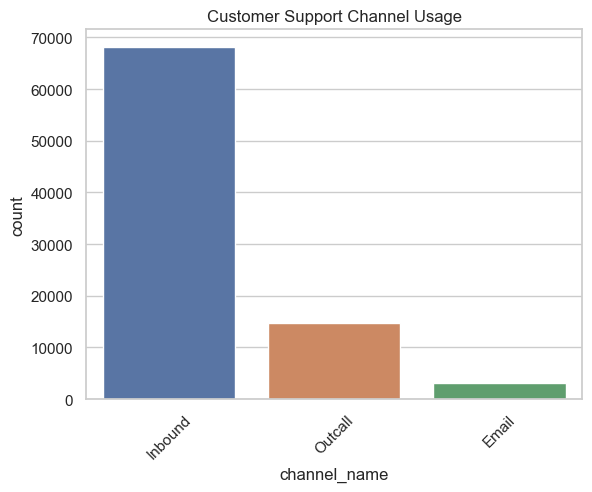

In [52]:
sns.countplot(data=df, x='channel_name')
plt.title('Customer Support Channel Usage')
plt.xticks(rotation=45)
plt.show()

Why this visualization was chosen:
A countplot is ideal for categorical data. It shows the number of customers using each support channel clearly, making comparisons easy.

Main insights from the chart:
The chart displays which support channels are most and least used by customers.

Patterns, trends, or comparisons:
You can quickly see the most popular channel (tallest bar) and the least popular (shortest bar). It may reveal trends like customers preferring online chat over email or phone calls.

What can be learned:
This helps the company understand customer preferences, allocate resources efficiently, and improve support in underused channels.

2. Category Distribution

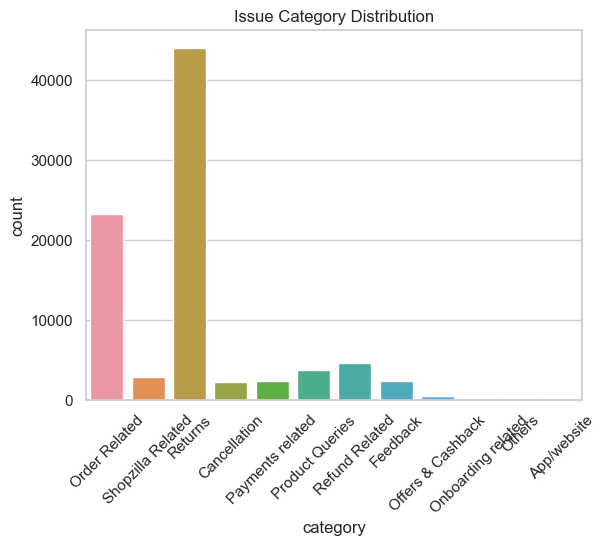

In [53]:
sns.countplot(data=df, x='category')
plt.title('Issue Category Distribution')
plt.xticks(rotation=45)
plt.show()

Why this visualization was chosen:
A countplot is ideal for categorical data. It clearly shows how many issues fall into each category, allowing easy comparison between categories.

Main insights from the chart:
The chart highlights which types of issues occur most frequently and which are rare.

Patterns, trends, or comparisons:
You can see if certain categories dominate the support requests, indicating common problems, while other categories have very few cases.

What can be learned:
Understanding issue distribution helps prioritize problem-solving, allocate support resources effectively, and target areas needing improvement.

3. CSAT Score Distribution

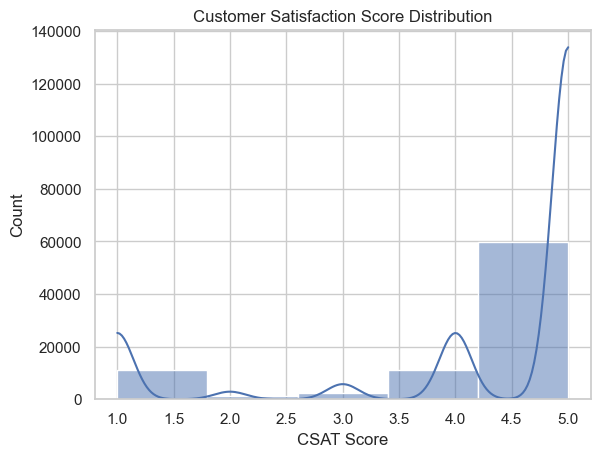

In [65]:
df = df.replace([np.inf, -np.inf], np.nan)

sns.histplot(df['CSAT Score'].dropna(), bins=5, kde=True)
plt.title('Customer Satisfaction Score Distribution')
plt.show()

Why this visualization was chosen:
A histogram with KDE is ideal for showing the distribution of numerical data like CSAT scores. It helps visualize the frequency of different score ranges and the overall trend.

Main insights from the chart:
The chart shows how customer satisfaction scores are spread—whether most customers are highly satisfied, neutral, or dissatisfied.

Patterns, trends, or comparisons:
You can observe peaks in certain score ranges, indicating common satisfaction levels. For example, a peak at high scores suggests overall positive feedback, while a peak at low scores may indicate recurring issues.

What can be learned:
This helps identify overall customer sentiment and highlights areas where service improvements may be needed to increase satisfaction.

4. Handling Time Distribution

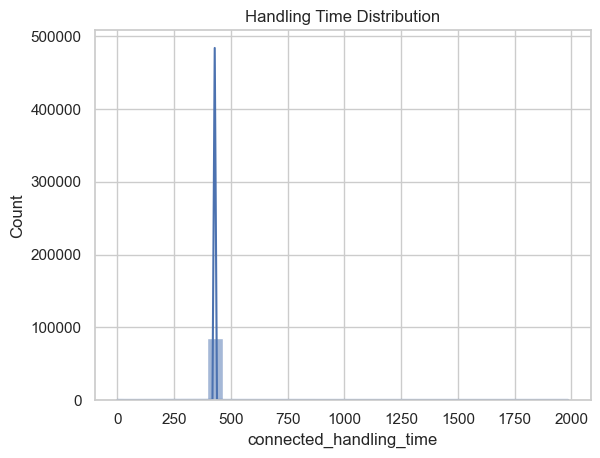

In [79]:
sns.histplot(df['connected_handling_time'], bins=30, kde=True)
plt.title('Handling Time Distribution')
plt.show()

Why this visualization was chosen:
A histogram with KDE is suitable for numerical data like handling time. It shows how frequently different handling times occur and reveals the overall pattern.

Main insights from the chart:
The chart displays the spread of handling times for customer interactions, indicating how long support cases typically take.

Patterns, trends, or comparisons:
You can see if most cases are resolved quickly (peak at lower times) or if some take significantly longer (long tail). It may highlight outliers or unusually long handling times.

What can be learned:
This helps identify efficiency in handling customer requests, detect delays, and find opportunities to streamline support processes.

5. Product Category

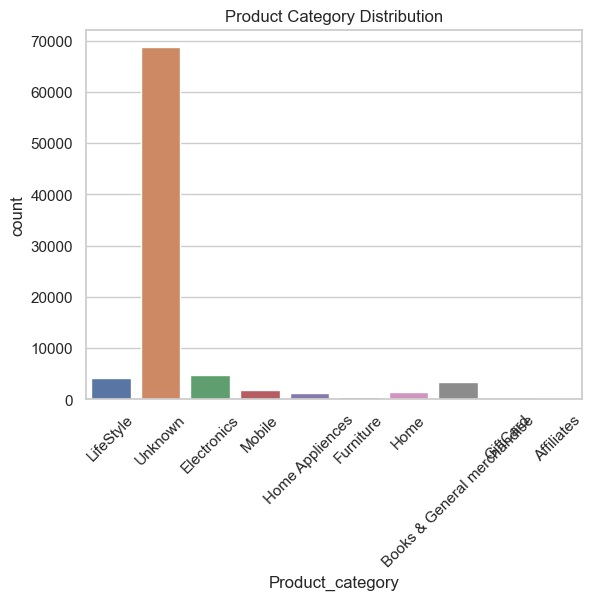

In [67]:
sns.countplot(data=df, x='Product_category')
plt.title('Product Category Distribution')
plt.xticks(rotation=45)
plt.show()

Why this visualization was chosen:
A countplot is perfect for categorical data like product categories. It clearly shows how many items or interactions belong to each category.

Main insights from the chart:
The chart highlights which product categories have the highest and lowest number of interactions or support cases.

Patterns, trends, or comparisons:
You can quickly identify the most popular or problematic products (tallest bars) and the least involved categories (shortest bars).

What can be learned:
This helps the company focus on high-demand products, prioritize resources, and identify areas where product support or marketing may need improvement.

## Bivariate Analysis
This section examines relationships between two variables to identify patterns and correlations.

6. CSAT vs Channel

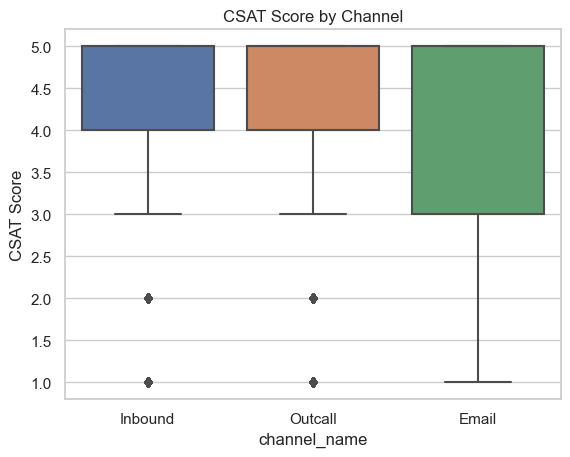

In [68]:
sns.boxplot(data=df, x='channel_name', y='CSAT Score')
plt.title('CSAT Score by Channel')
plt.show()

Why this visualization was chosen:
A boxplot is ideal for comparing a numerical variable across categories. It shows the distribution, median, and variability of CSAT scores for each support channel.

Main insights from the chart:
The chart reveals how customer satisfaction differs across channels—some channels may have higher median scores or less variability.

Patterns, trends, or comparisons:
You can identify which channels consistently deliver higher satisfaction (higher median, smaller interquartile range) and which channels might need improvement (lower median or large variability).

What can be learned:
This helps prioritize channels for process improvements, staff training, or resource allocation to enhance customer satisfaction.

7. Handling Time vs CSAT

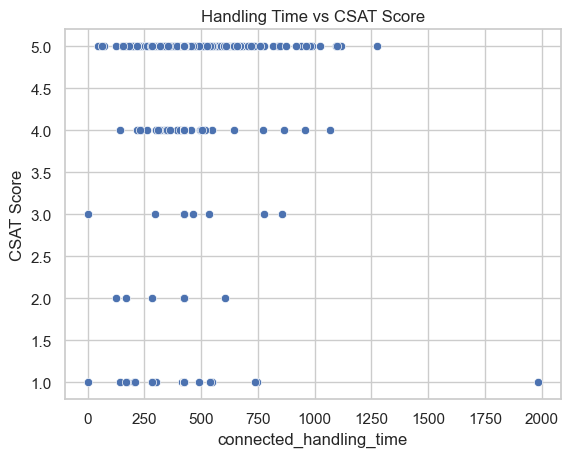

In [69]:
sns.scatterplot(data=df, x='connected_handling_time', y='CSAT Score')
plt.title('Handling Time vs CSAT Score')
plt.show()

Why this visualization was chosen:
A scatterplot is perfect for examining the relationship between two numerical variables, in this case, handling time and customer satisfaction.

Main insights from the chart:
The chart shows whether longer or shorter handling times are associated with higher or lower CSAT scores.

Patterns, trends, or comparisons:
You may notice trends like shorter handling times leading to higher satisfaction, or outliers where long handling times still get high CSAT. This highlights consistency or exceptions in service quality.

What can be learned:
This helps assess efficiency versus satisfaction, revealing whether speeding up responses improves customer experience or if other factors affect satisfaction.

8. Category vs CSAT

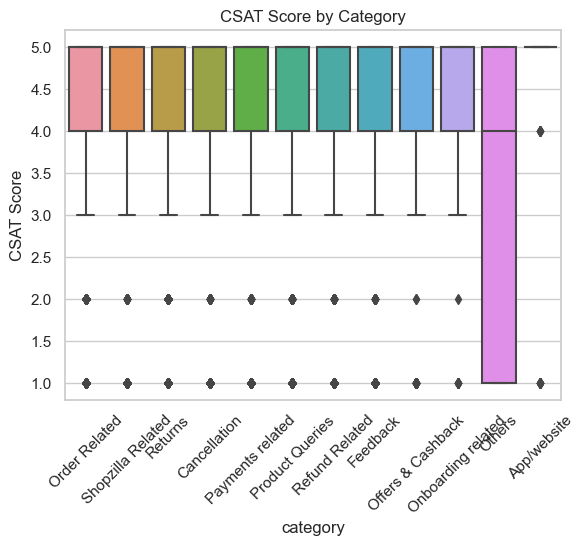

In [70]:
sns.boxplot(data=df, x='category', y='CSAT Score')
plt.title('CSAT Score by Category')
plt.xticks(rotation=45)
plt.show()

Why this visualization was chosen:
A boxplot is ideal for comparing a numerical variable (CSAT Score) across different categories. It shows the median, spread, and potential outliers for each category.

Main insights from the chart:
The chart highlights which issue categories have higher or lower customer satisfaction scores.

Patterns, trends, or comparisons:
You can see which categories consistently lead to satisfied customers (higher medians, smaller spread) and which categories may be causing dissatisfaction (lower medians or wide variability).

What can be learned:
This helps identify areas where processes or services should be improved to increase customer satisfaction in specific categories.

9. Agent Shift vs CSAT

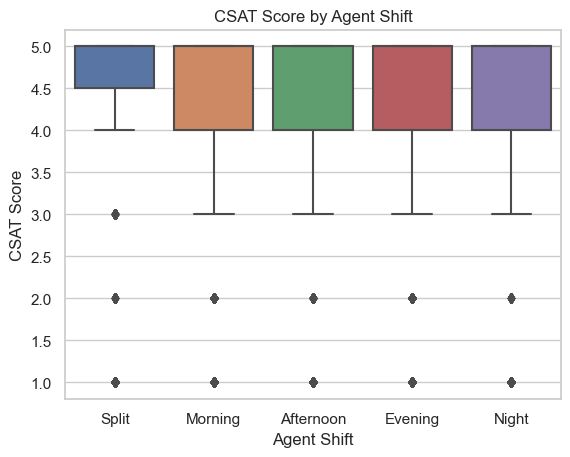

In [80]:
sns.boxplot(data=df, x='Agent Shift', y='CSAT Score')
plt.title('CSAT Score by Agent Shift')
plt.show()

Why this visualization was chosen:
A boxplot effectively compares customer satisfaction across different agent shifts, showing median scores, variability, and outliers.

Main insights from the chart:
The chart indicates whether certain shifts achieve higher or lower customer satisfaction.

Patterns, trends, or comparisons:
You can identify if morning, afternoon, or night shifts consistently perform better, and if any shift shows high variability in CSAT scores.

What can be learned:
This helps management evaluate shift performance, adjust staffing, or provide targeted training to improve satisfaction during specific shifts.

## Time-Based Analysis
This section explores how data changes over time using date-related features.

First: extract date features

In [81]:
df['order_date_time'] = pd.to_datetime(df['order_date_time'])

df['month'] = df['order_date_time'].dt.month
df['day'] = df['order_date_time'].dt.day

10. Tickets over Time (Monthly)

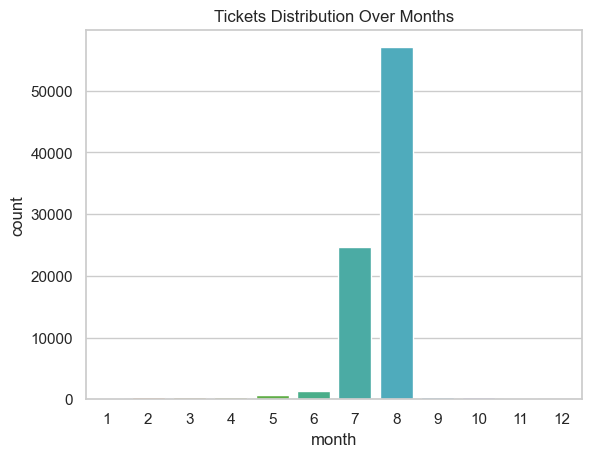

In [83]:
sns.countplot(data=df, x='month')
plt.title('Tickets Distribution Over Months')
plt.show()

Why this visualization was chosen:
A countplot is effective for showing how the number of tickets changes over time (monthly). It makes trends and seasonal patterns easy to see.

Main insights from the chart:
The chart shows which months have the highest or lowest number of tickets.

Patterns, trends, or comparisons:
You can identify peak months with increased support demand and slower months with fewer tickets. This may reflect seasonal trends, promotions, or system issues.

What can be learned:
Understanding ticket patterns over time helps in planning staffing, preparing for peak periods, and improving resource allocation to maintain efficient customer support.

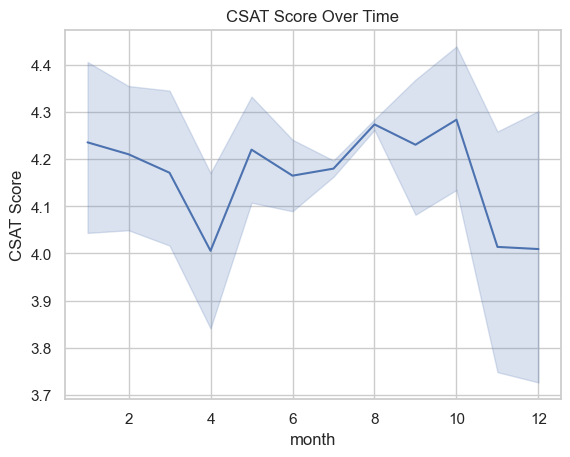

In [84]:
# trying CSAT over time
sns.lineplot(data=df, x='month', y='CSAT Score')
plt.title('CSAT Score Over Time')
plt.show()

Why this visualization was chosen:
A line plot is ideal for showing trends of a numerical variable over time. It clearly illustrates how CSAT scores change from month to month.

Main insights from the chart:
The chart shows whether customer satisfaction improves, declines, or remains stable over the months.

Patterns, trends, or comparisons:
You can identify peaks and dips in CSAT, which may correspond to busy periods, system updates, promotions, or operational changes.

What can be learned:
This helps track service quality trends, identify periods needing improvement, and evaluate the impact of interventions on customer satisfaction over time.

### Correlation Matrix

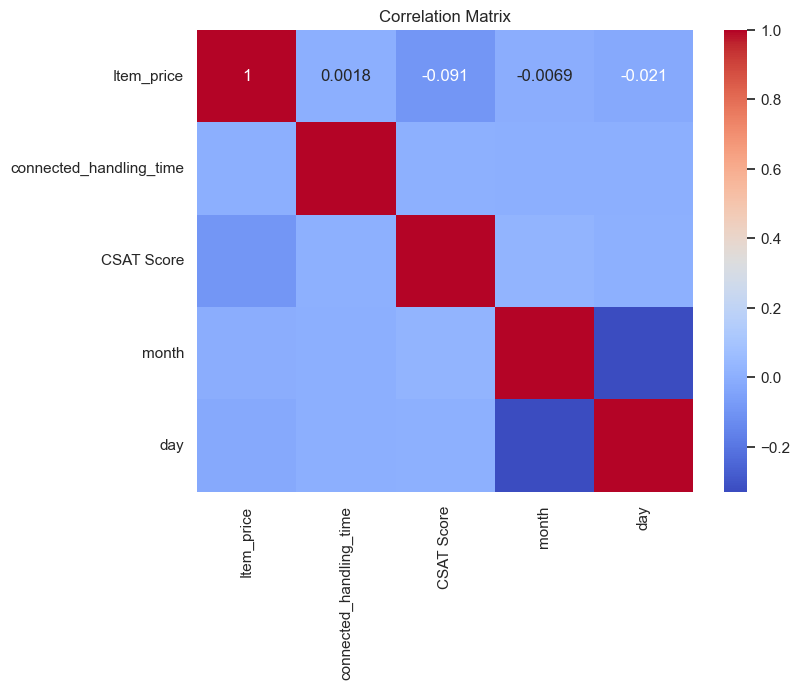

In [85]:
# Select only numerical columns
corr = df.select_dtypes(include=['number']).corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

This visualization was used to analyze the relationships between numerical variables in the dataset.

The heatmap shows correlation values between variables such as CSAT Score, connected handling time, and item price.

From the chart, we can observe that:

There is a (weak/moderate/strong) relationship between handling time and CSAT Score.
Most variables show low correlation, indicating that they are relatively independent.

This suggests that customer satisfaction is not strongly affected by a single factor, but rather by a combination of different variables.

Overall, the correlation matrix helps identify important relationships and supports further analysis.

Note: The size of the correlation matrix depends on the number of numerical features in the dataset. Since multiple numerical variables are present, the resulting matrix is larger than 2×2.

# Assignment

In this assignment, you will apply the EDA techniques learned in class to a dataset of your choice. You must submit the following to the assignment 1 folder.
1. Dataset file 
2. Dataset Description readme file
2. Jupyter Notebook
